In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'
from scipy.stats import ks_2samp
# df = pd.read_csv("./results/tf_summary_all_conditions.csv")
# heat = df.pivot(index='TF', columns='condition', values='z_score')

# plt.figure(figsize=(10, len(heat) * 0.2))
# sns.heatmap(heat, center=0, cmap="vlag", linewidths=0.5, linecolor='gray')
# plt.title("Z-scores of TF Activity (Observed vs Randomized)")
# plt.tight_layout()
# plt.show()

In [3]:
%run Shuffle.py

/home/mmultari/miniconda3/envs/GRN/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🔍 Running real TF activity...
Running ulm on mat with 7 samples and 1786 targets for 68 sources.
🔁 Running 1000 random shuffles with multiprocessing...
📊 Computing summary statistics...
✅ Benchmark complete.


In [4]:
results_run_ref = pd.read_csv("../TDA/Results_hubs_activity_stats_mega_cluster-SUPP_table.tsv", sep="\t")
df = pd.read_csv("./results/tf_summary_all_conditions.csv")
# heat = df.pivot(index='TF', columns='condition', values='z_score')

In [5]:
df_signif=df[df['TF'].isin(results_run_ref[results_run_ref['Groups'].notna()]['OLN'])]

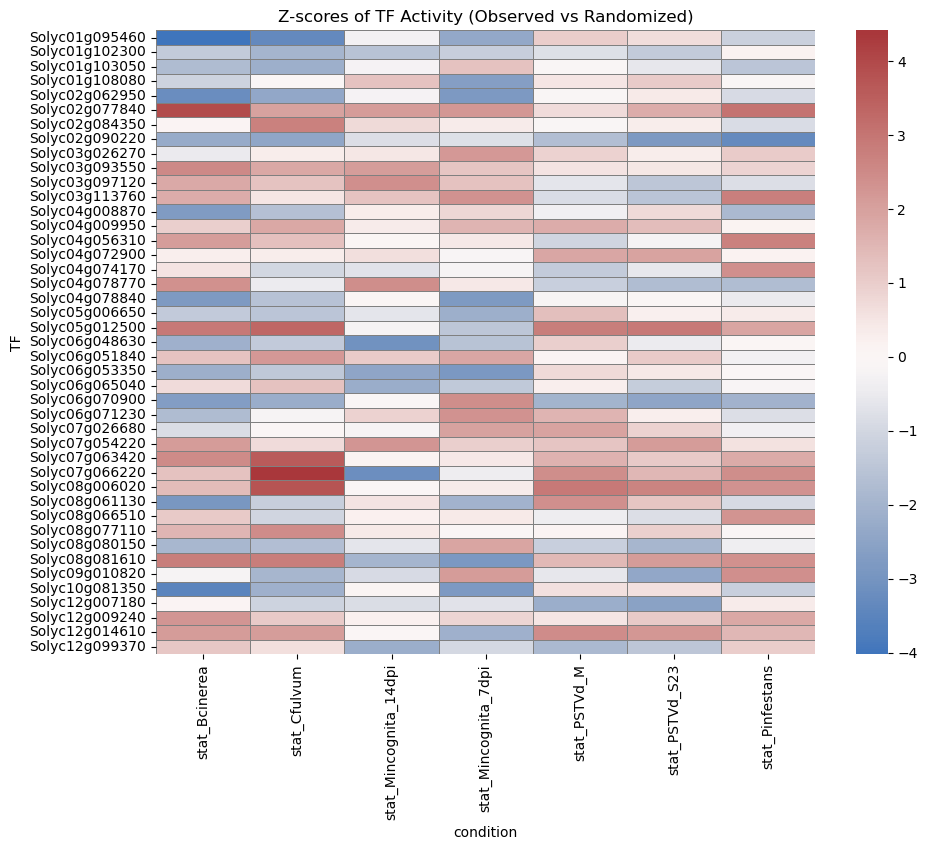

In [6]:
heat = df_signif.pivot(index='TF', columns='condition', values='z_score')

plt.figure(figsize=(10, len(heat) * 0.2))
sns.heatmap(heat, center=0, cmap="vlag", linewidths=0.5, linecolor='gray')
plt.title("Z-scores of TF Activity (Observed vs Randomized)")
plt.tight_layout()
plt.show()

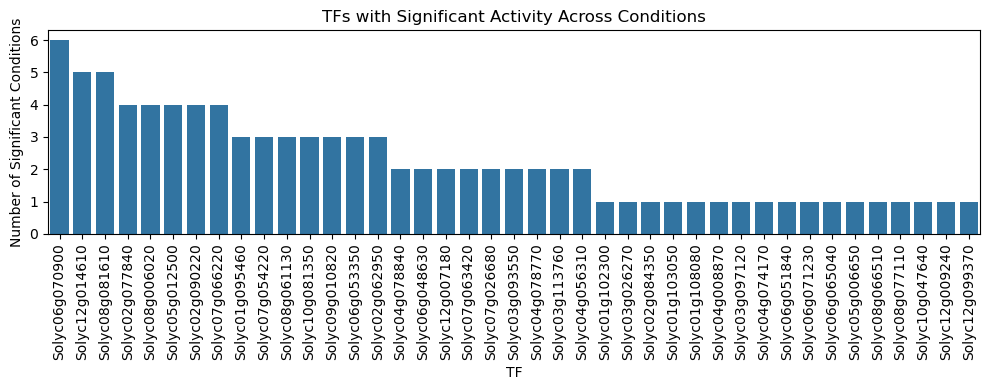

In [7]:
sig_count = df[df['significant']].groupby('TF')['condition'].nunique().sort_values(ascending=False)

plt.figure(figsize=(10, 4))
sns.barplot(x=sig_count.index, y=sig_count.values)
plt.xticks(rotation=90)
plt.ylabel("Number of Significant Conditions")
plt.title("TFs with Significant Activity Across Conditions")
plt.tight_layout()
plt.show()

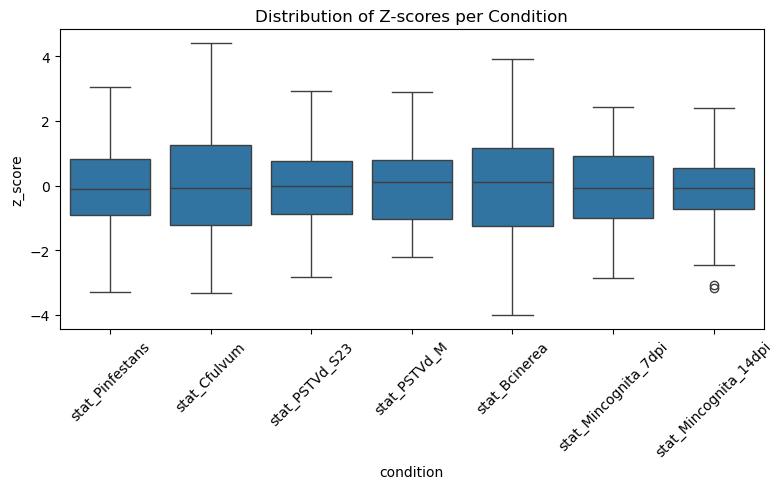

In [8]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='condition', y='z_score', data=df)
plt.xticks(rotation=45)
plt.title("Distribution of Z-scores per Condition")
plt.tight_layout()
plt.show()

In [9]:
results = pd.read_csv('../TDA/Results_hubs_activity_stats_mega_cluster-SUPP_table.tsv', sep='\t')
results = results[results['OLN'].isin(heat.index)]
results.set_index('OLN', inplace=True)
pval = results.iloc[:,29:36]
pval = pval <= 0.05
pval = pval[sorted(pval.columns)]

In [10]:
heat_pval_emp = df.pivot(index='TF', columns='condition', values='significant')
heat_pval_emp = heat_pval_emp[heat_pval_emp.index.isin(heat.index)]

In [11]:
# heat_iqr = df.pivot(index='TF', columns='condition', values='iqr_outlier')
# heat_iqr = heat_iqr[heat_iqr.index.isin(heat.index)]
# heat_mad = df.pivot(index='TF', columns='condition', values='mad_outlier')
# heat_mad = heat_mad[heat_mad.index.isin(heat.index)]

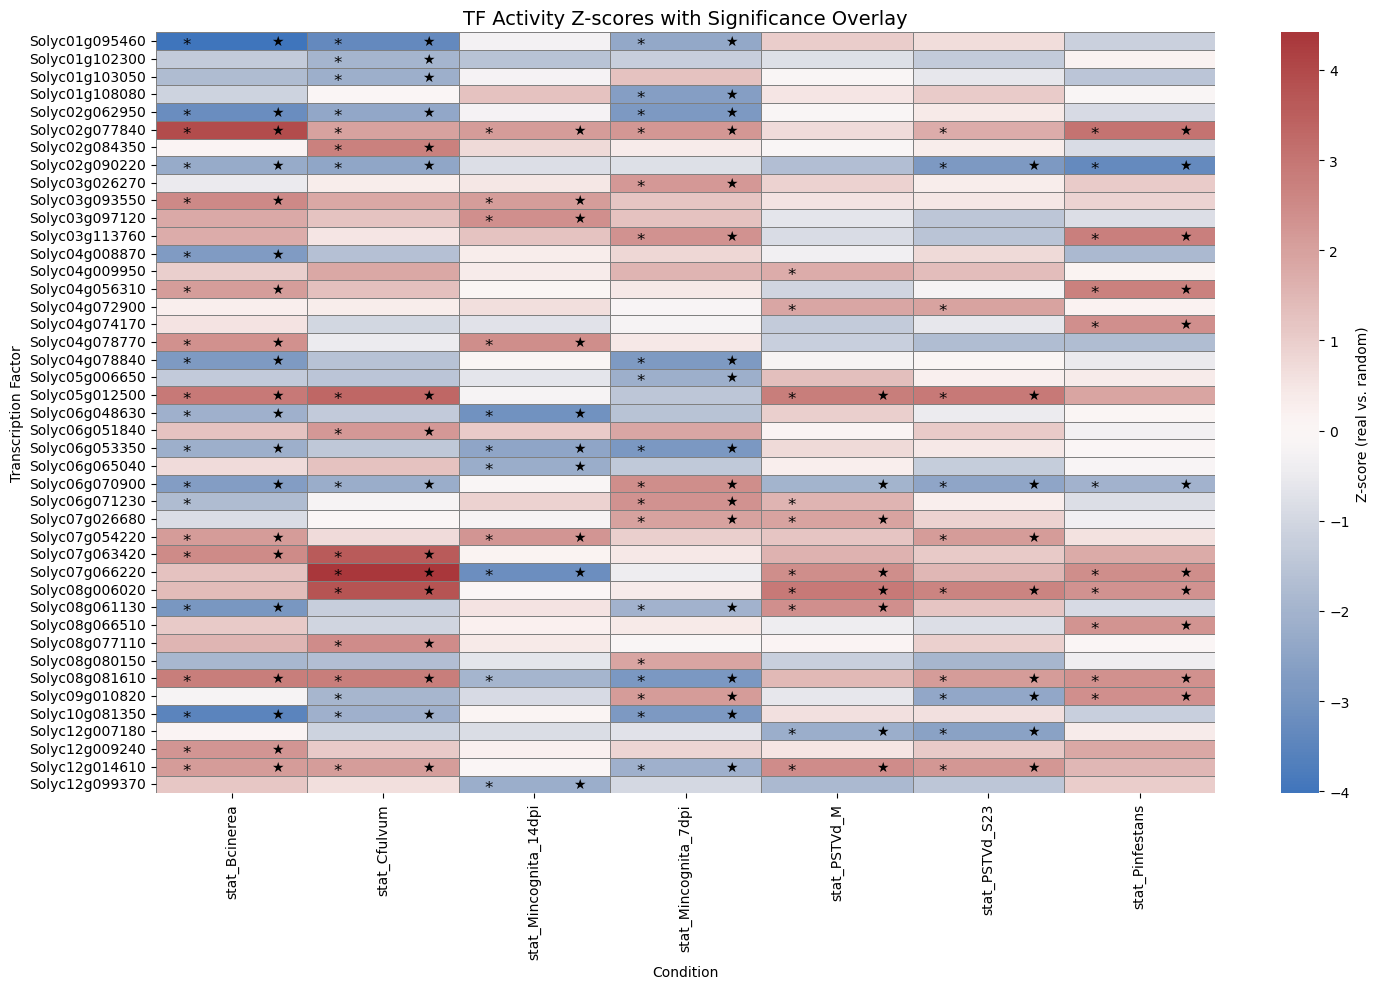

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Example: z_score_df and significance_df should have the same shape and matching index/columns

plt.figure(figsize=(15, 10))

# Create the heatmap of z-scores
ax = sns.heatmap(
    heat,
    cmap="vlag", center=0,
    linewidths=0.5, linecolor='gray',
    cbar_kws={'label': 'Z-score (real vs. random)'}
)

# Overlay stars for significance (adjust fontsize/style as needed)
for y in range(heat.shape[0]):
    for x in range(heat.shape[1]):
        if pval.iloc[y, x]:
            ax.text(x + 0.2, y + 0.7, '*', color='black',
                    ha='center', va='center', fontsize=12)
            
for y in range(heat.shape[0]):
    for x in range(heat.shape[1]):
        if heat_pval_emp.iloc[y, x]:
            ax.text(x + 0.8, y + 0.5, '★', color='black',
                    ha='center', va='center', fontsize=10)
            
# for y in range(heat.shape[0]):
#     for x in range(heat.shape[1]):
#         if heat_iqr.iloc[y, x]:
#             ax.text(x + 0.4, y + 0.5, '♠', color='black',
#                     ha='center', va='center', fontsize=10)
            
# for y in range(heat.shape[0]):
#     for x in range(heat.shape[1]):
#         if heat_mad.iloc[y, x]:
#             ax.text(x + 0.6, y + 0.5, '♣', color='black',
#                     ha='center', va='center', fontsize=10)

plt.title("TF Activity Z-scores with Significance Overlay", fontsize=14)
plt.xlabel("Condition")
plt.ylabel("Transcription Factor")
plt.tight_layout()
plt.savefig('./Heatmap_shuffle_zscore_with_significance.svg', format='svg')
plt.show()

In [13]:
pval_violin = pval.reset_index().melt(id_vars='OLN', var_name='condition', value_name='significant')
pval_violin['condition'] = pval_violin['condition'].str.replace('_pval','')

In [14]:
real_score = pd.read_csv("./results/real_activity_all_conditions.csv")
randomized_score = pd.read_csv("./results/null_distribution_all_conditions.csv")
real_score['type']='real'
randomized_score['type']='random'

In [15]:
df_all = pd.concat([real_score[['source','condition','score','type']],randomized_score[['source','condition','score','type']]], ignore_index=True)
df_all['condition'] = df_all['condition'].str.replace('stat_','')
df_all = df_all.merge(pval_violin, left_on=['source', 'condition'], right_on=['OLN', 'condition'])
df_signif_all = df_all[df_all['significant']]

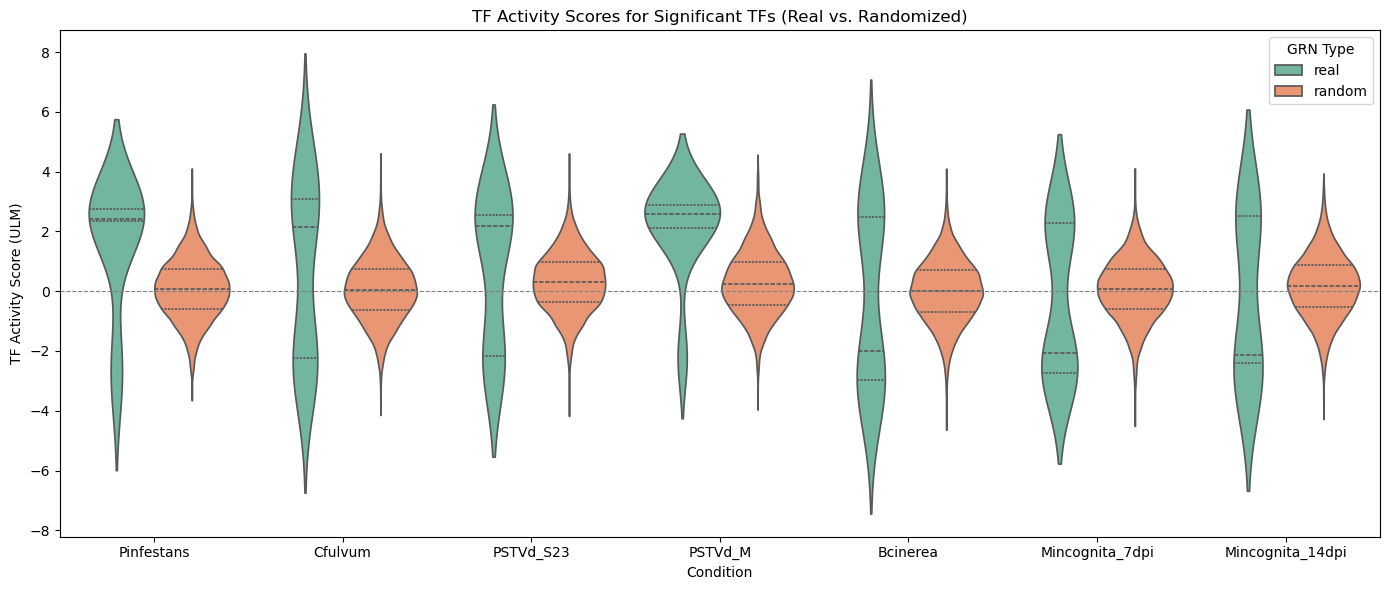

In [16]:
plt.figure(figsize=(14, 6))
sns.violinplot(
    data=df_signif_all,
    x='condition',
    y='score',
    hue='type',
    split=False,
    inner='quartile',
    palette='Set2'
)

plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.title("TF Activity Scores for Significant TFs (Real vs. Randomized)")
plt.ylabel("TF Activity Score (ULM)")
plt.xlabel("Condition")
plt.legend(title="GRN Type")
plt.tight_layout()
plt.savefig('./Violin_shuffle_activity.svg', format='svg')
plt.show()

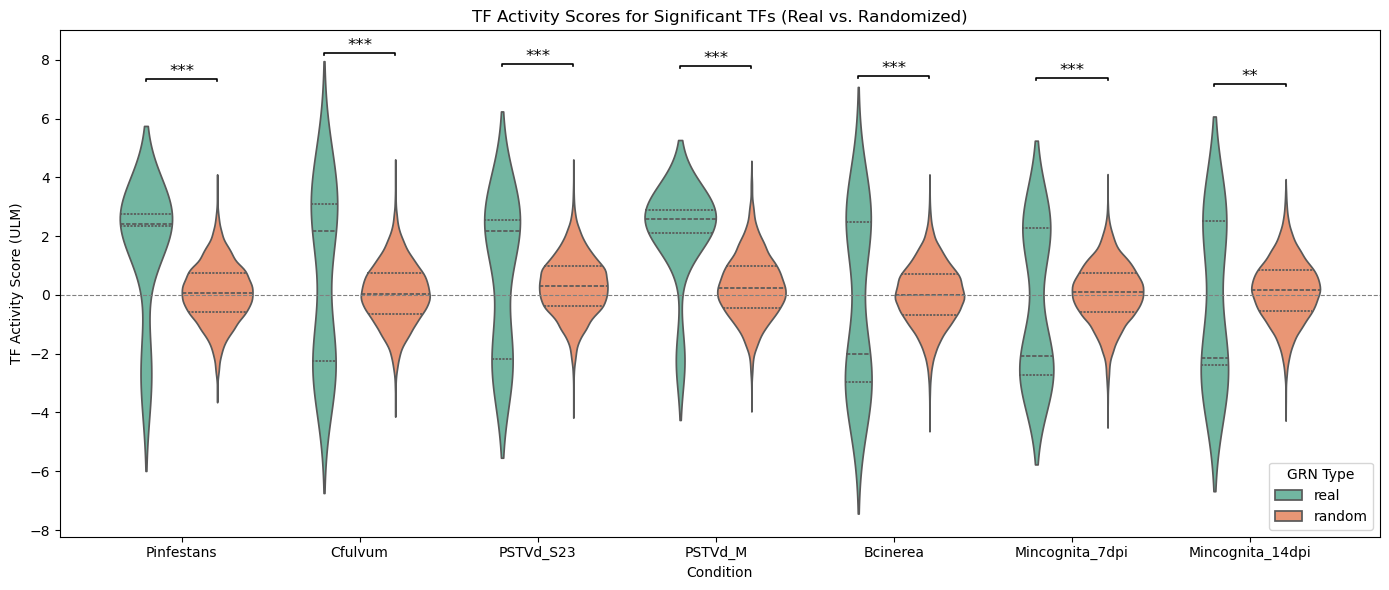

In [25]:
# --- Run KS tests per condition ---
ks_results = []
for cond in df_signif_all['condition'].unique():
    real_vals = df_signif_all[(df_signif_all['condition'] == cond) & (df_signif_all['type'] == 'real')]['score']
    rand_vals = df_signif_all[(df_signif_all['condition'] == cond) & (df_signif_all['type'] == 'random')]['score']
    stat, pval = ks_2samp(real_vals, rand_vals)
    ks_results.append({"condition": cond, "KS_statistic": stat, "p_value": pval})

ks_df = pd.DataFrame(ks_results)

# --- Map p-values to stars ---
def significance_label(pval):
    if pval < 0.001:
        return "***"
    elif pval < 0.01:
        return "**"
    elif pval < 0.05:
        return "*"
    else:
        return "ns"

# --- Plot violin ---
plt.figure(figsize=(14, 6))
ax = sns.violinplot(
    data=df_signif_all,
    x='condition',
    y='score',
    hue='type',
    split=False,
    inner='quartile',
    palette='Set2'
)

plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.title("TF Activity Scores for Significant TFs (Real vs. Randomized)")
plt.ylabel("TF Activity Score (ULM)")
plt.xlabel("Condition")
plt.legend(title="GRN Type")

# --- Helper function to draw brackets ---
def add_stat_annotation(ax, x1, x2, y, h, text):
    """Draws a bracket between x1 and x2 at height y+h with a significance label."""
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.2, c='black')
    ax.text((x1 + x2) * 0.5, y + h + 0.02, text,
            ha='center', va='bottom', color='black', fontsize=12)

# --- Add significance brackets per condition ---
for i, row in ks_df.iterrows():
    cond = row['condition']
    pval = row['p_value']
    label = significance_label(pval)

    # violinplot places two violins per condition side by side → positions are like 0,1,2... with offsets
    cond_positions = [p for p, c in enumerate(df_signif_all['condition'].unique()) if c == cond][0]

    # The two violins (real vs random) are slightly shifted left/right around cond_positions
    x1, x2 = cond_positions - 0.2, cond_positions + 0.2
    
    # Compute height for bracket
    y_max = df_signif_all[df_signif_all['condition'] == cond]['score'].max()
    add_stat_annotation(ax, x1, x2, y=y_max + 3.5, h=0.05, text=label)

plt.tight_layout()
plt.savefig('./Violin_shuffle_activity_with_brackets.svg', format='svg')
plt.show()

In [17]:
from scipy.stats import ks_2samp

# Store results
ks_results = []

# Loop over each condition
for cond in df_signif_all['condition'].unique():
    real_vals = df_signif_all[(df_signif_all['condition'] == cond) & (df_signif_all['type'] == 'real')]['score']
    rand_vals = df_signif_all[(df_signif_all['condition'] == cond) & (df_signif_all['type'] == 'random')]['score']
    
    # KS test
    stat, pval = ks_2samp(real_vals, rand_vals)
    ks_results.append({"condition": cond, "KS_statistic": stat, "p_value": pval})

# Convert to DataFrame for inspection
ks_df = pd.DataFrame(ks_results)
print(ks_df)

          condition  KS_statistic       p_value
0        Pinfestans      0.805455  3.275045e-08
1           Cfulvum      0.527778  3.348048e-05
2         PSTVd_S23      0.603818  2.270065e-04
3           PSTVd_M      0.843200  1.861724e-08
4          Bcinerea      0.494143  2.941774e-05
5   Mincognita_7dpi      0.534222  2.510528e-05
6  Mincognita_14dpi      0.528636  2.153572e-03


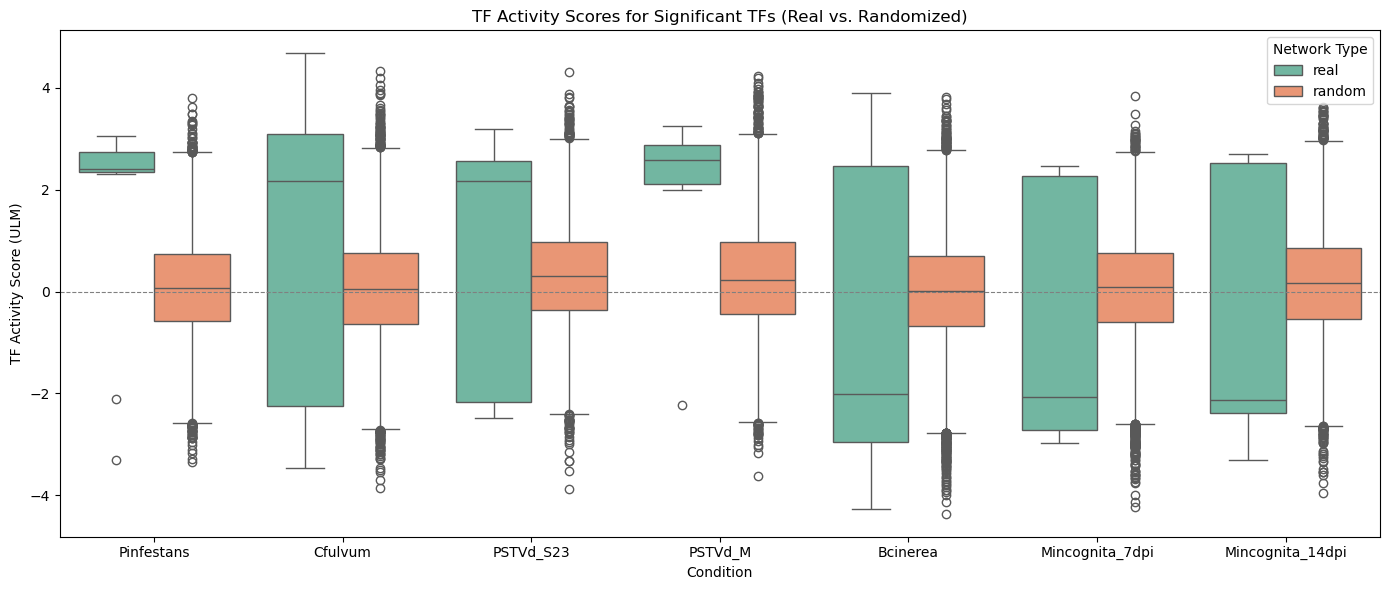

In [18]:
plt.figure(figsize=(14, 6))
sns.boxplot(
    data=df_signif_all,
    x='condition',
    y='score',
    hue='type',
    palette='Set2'
)

plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.title("TF Activity Scores for Significant TFs (Real vs. Randomized)")
plt.ylabel("TF Activity Score (ULM)")
plt.xlabel("Condition")
plt.legend(title="Network Type")
plt.tight_layout()
plt.show()